# 05 · Q3: Fraud
COO question: "Finance says fraud is costing us. How much, where is it coming from, and can we catch it before we ship?"

Fraud = orders with status SUSPECTED_FRAUD. Analysed per order.

In [1]:
%run common.py
con = connect()

## 8.1 How much fraud is there each year?

In [2]:
con.sql("""
    SELECT order_year,
           COUNT(*) AS orders,
           SUM(CASE WHEN is_fraud THEN 1 ELSE 0 END) AS fraud_orders,
           SUM(CASE WHEN is_fraud THEN revenue ELSE 0 END) AS fraud_value
    FROM orders
    GROUP BY order_year
    ORDER BY order_year
""").df()

,order_year,orders,fraud_orders,fraud_value
0,2015,20904,468.00,"239,270.43"
1,2016,20859,473.00,"239,417.58"
2,2017,21866,506.00,"256,466.73"
3,2018,2123,41.00,"6,337.57"


## 8.2 Fraud compared with profit (2017)

In [3]:
con.sql("""
    SELECT SUM(CASE WHEN is_fraud THEN revenue ELSE 0 END) AS fraud_value_2017,
           (SELECT SUM(item_profit) FROM order_items WHERE order_year = 2017) AS profit_2017,
           ROUND(SUM(CASE WHEN is_fraud THEN revenue ELSE 0 END)
                 / (SELECT SUM(item_profit) FROM order_items WHERE order_year = 2017) * 100, 1) AS fraud_pct_of_profit
    FROM orders
    WHERE order_year = 2017
""").df()

,fraud_value_2017,profit_2017,fraud_pct_of_profit
0,"256,466.73","1,304,085.11",19.70


## 8.3 Fraud by payment type

In [4]:
pay = con.sql("""
    SELECT payment_type,
           COUNT(*) AS orders,
           SUM(CASE WHEN is_fraud THEN 1 ELSE 0 END) AS fraud_orders,
           ROUND(AVG(CASE WHEN is_fraud THEN 1 ELSE 0 END) * 100, 1) AS fraud_pct
    FROM orders
    GROUP BY payment_type
    ORDER BY fraud_pct DESC
""").df()
pay

,payment_type,orders,fraud_orders,fraud_pct
0,TRANSFER,18077,"1,488.00",8.20
1,PAYMENT,15086,0.00,0.00
2,DEBIT,25340,0.00,0.00
3,CASH,7249,0.00,0.00


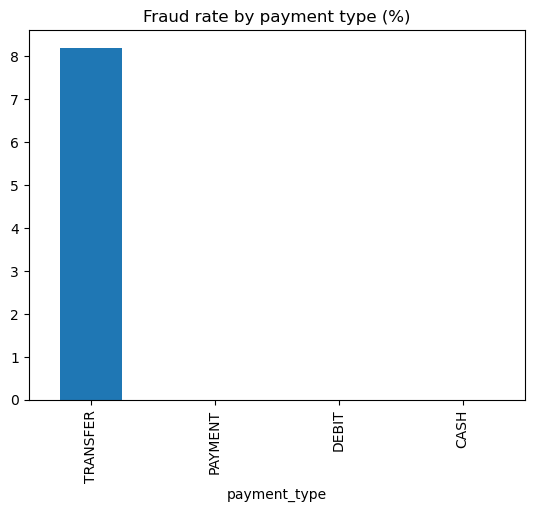

In [5]:
pay.plot.bar(x='payment_type', y='fraud_pct', title='Fraud rate by payment type (%)', legend=False)
plt.savefig(FIG + 'q3_fraud_by_payment.png', bbox_inches='tight')

## 8.4 Within bank transfers, does market matter?

In [6]:
con.sql("""
    SELECT market,
           COUNT(*) AS transfer_orders,
           ROUND(AVG(CASE WHEN is_fraud THEN 1 ELSE 0 END) * 100, 1) AS fraud_pct
    FROM orders
    WHERE payment_type = 'TRANSFER'
    GROUP BY market
    ORDER BY fraud_pct DESC
""").df()

,market,transfer_orders,fraud_pct
0,USCA,2384,8.80
1,Europe,5004,8.50
2,LATAM,4833,8.20
3,Africa,1092,7.90
4,Pacific Asia,4764,7.70


## 8.5 Test the rule: review every bank-transfer order (2017)
- **Recall:** what share of fraud orders the rule catches
- **Precision:** what share of reviewed orders are actually fraud

In [7]:
con.sql("""
    SELECT COUNT(*) AS orders_reviewed,
           ROUND(COUNT(*) / 52) AS per_week,
           SUM(CASE WHEN is_fraud THEN 1 ELSE 0 END) AS fraud_caught,
           ROUND(AVG(CASE WHEN is_fraud THEN 1 ELSE 0 END) * 100, 1) AS pct_fraud
    FROM orders
    WHERE order_year = 2017 AND payment_type = 'TRANSFER'
""").df()

,orders_reviewed,per_week,fraud_caught,pct_fraud
0,6134,118.00,506.00,8.20


## 8.6 What I did not use, and why
Every fraud order has Delivery Status "Shipping canceled". But that status is set *after* the fraud decision, so using it to "predict" fraud would be cheating: it would look perfect but could never work in real life. This is called **data leakage**. I only used information known **before** an order ships, such as payment type and market.

## Answer for the COO
- **How much:** about $256K of suspected fraud in 2017, equal to about a fifth of the year's profit.
- **Where from:** 100% of fraud is paid by bank transfer; about 8% of transfer orders are fraud. Nothing else (market, shipping mode, segment) makes a real difference.
- **Can we catch it?** Yes: hold every bank-transfer order until the payment clears. This would have caught all 506 fraud orders in 2017, at a cost of about 118 checks a week (1 in 12 finds fraud).
- **Also consider:** encouraging card payments at checkout, to shrink the review queue.
- Note: in this dataset, payment type fully decides order status, which suggests simulated data. Real fraud would need richer signals (device, IP address, address mismatches).

## Future step (optional)
Test a simple decision tree to confirm no combination of factors beats the bank-transfer rul